In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import compress_pickle as pickle  
import mplhep as hep
import math
from scipy.optimize import curve_fit
import compress_pickle
import pickle
import gzip
hep.style.use("CMS")
from helpers import *

### Note: This notebook assumes the theta values used are in mrad when calculating eta and plotting theta!
### Note: All models except the August 2025 models have an error where part of theta distribution was being cut due to the THETA_MAX value

In [2]:
# Format is (particle, input feature dimensions, output feature dimensions, theta_low, theta_high, high/low granularity, already_rotated, date, theta mask during training)
conditions = {
    ('neutron', '4D', '3D', 2.3, 4.25, 'high_granularity', True, "August 2024", False):{
    'result_dir': '/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2024_small_eta/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2024_small_eta/',
    'discrete_data':'/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/fullepic_multiseg_neutron_log10discrete_1GeV-150GeV_2.3deg-4.25deg_08_28_2024/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/fullepic_multiseg_neutron_log10continuous_1GeV-150GeV_2.3deg-4.25deg_08_27_2024/'
    },
    ('neutron', '4D', '3D', 2.3, 4.25, 'high_granularity', False, "August 2024", False):{
    'result_dir':'/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2024_small_eta_norotation/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2024_small_eta_norotation/',
    'discrete_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/fullepic_multiseg_neutron_log10discrete_1GeV-150GeV_2.3deg-4.25deg_08_28_2024/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/fullepic_multiseg_neutron_log10continuous_1GeV-150GeV_2.3deg-4.25deg_08_27_2024/'
    },
    ('neutron', '4D', '3D', 1.273, 5.7, 'high_granularity', False, "August 2025", False):{
    'result_dir':'/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2025_extended_eta_correctedSF_nomaxtheta/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2025_extended_eta_correctedSF_nomaxtheta/',
    'discrete_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10discrete_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_dataepicforward_inserthighgranularity_neutron_log10continuous_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/'
    },
    ('neutron', '4D', '3D', 1.273, 5.7, 'high_granularity', False, "August 2025", True):{
    'result_dir':'/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2025_extended_eta_correctedSF_etamask_nomaxtheta/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2025_extended_eta_correctedSF_etamask_nomaxtheta/',
    'discrete_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10discrete_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_neutron_log10continuous_1GeV-150GeV_1.273deg-5.7deg_08_05_2025/'
    },
    ('neutron', '4D', '3D', 1.273, 5.7, 'low_granularity', False, "August 2025", False):{
    'result_dir':'/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2025_lowgranularity_extended_eta_correctedSF_nomaxtheta/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2025_lowgranularity_extended_eta_correctedSF_nomaxtheta/',
    'discrete_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_insertlowgranularity_neutron_log10discrete_1GeV-150GeV_1.273deg-5.7deg_08_06_2025/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_insertlowgranularity_neutron_log10continuous_1GeV-150GeV_1.273deg-5.7deg_08_06_2025/'
    },
    ('neutron', '4D', '3D', 1.273, 5.7, 'low_granularity', False, "August 2025", True):{
    'result_dir':'/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2025_lowgranularity_extended_eta_correctedSF_etamask_nomaxtheta/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2025_lowgranularity_extended_eta_correctedSF_etamask_nomaxtheta/',
    'discrete_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_insertlowgranularity_neutron_log10discrete_1GeV-150GeV_1.273deg-5.7deg_08_06_2025/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_insertlowgranularity_neutron_log10continuous_1GeV-150GeV_1.273deg-5.7deg_08_06_2025/'
    },
    ('neutron', '4D', '3D', 1.273, 5.7, 'high_granularity', False, "August 2024", False):{
    'result_dir': '/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2024_extended_eta/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2024_extended_eta/',
    'discrete_data':'/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/fullepic_multiseg_neutron_log10discrete_1GeV-150GeV_1.273deg-5.7deg_09_09_2024/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/fullepic_multiseg_neutron_log10continuous_1GeV-150GeV_1.273deg-5.7deg_09_09_2024/'
    },
    ('neutron', '4D', '3D', 1.273, 5.7, 'high_granularity', True, "August 2024", False):{
    'result_dir': '/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2024_extended_eta_norotation/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/august2024_extended_eta/',
    'discrete_data':'/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/fullepic_multiseg_neutron_log10discrete_1GeV-150GeV_1.273deg-5.7deg_09_09_2024/',
    'continuous_data': '/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/fullepic_multiseg_neutron_log10continuous_1GeV-150GeV_1.273deg-5.7deg_09_09_2024/'
    },
}
default_entry = {
    'result_dir': 'No_File',
    'preprocessed_dir': 'No_Title',
}

In [3]:
particle ='neutron'  # pi+,  pi0, neutron, gamma
input_features='4D'  ## input features [4D, 2D, 1D]
output_dim='3D'    ## '1D', '2D', '3D'
theta_low=1.273
theta_high=5.7
granularity='high_granularity'
already_rotated=False
date = "August 2025"
theta_mask = False

entry = conditions.get((particle,
                        input_features,
                        output_dim,
                        theta_low,
                        theta_high,
                        granularity,
                        already_rotated,
                        date,
                        theta_mask),
                       default_entry)
path_to_result = entry['result_dir']
path_to_stat = entry['preprocessed_dir']

if entry['result_dir'] == 'No_File':
    print('File not found')    

print(path_to_result)  

/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/august2025_extended_eta_correctedSF_nomaxtheta/


In [4]:
# Will likely need to change name of npz file for your use case
npz_unpacked = np.load(path_to_result+"/predictions_appended_test.npz") 

predictions_unnormalized = npz_unpacked['outputs_scaled']
targets_unnormalized = npz_unpacked['targets_scaled']

if output_dim == '3D':
    targets_energy = targets_unnormalized[:,0]
    targets_theta = targets_unnormalized[:,1]
    targets_phi = targets_unnormalized[:,2]

    predictions_energy = predictions_unnormalized[:,0]
    predictions_theta = predictions_unnormalized[:,1]
    predictions_phi = predictions_unnormalized[:,2]
elif output_dim == '2D':
    targets_energy = targets_unnormalized[:,0]
    targets_theta = targets_unnormalized[:,1]

    predictions_energy = predictions_unnormalized[:,0]
    predictions_theta = predictions_unnormalized[:,1]
elif output_dim == '1D':
    targets_energy = targets_unnormalized
    predictions_energy = predictions_unnormalized
else:
    print("Output dimensions isn't 1D, 2D, or 3D")

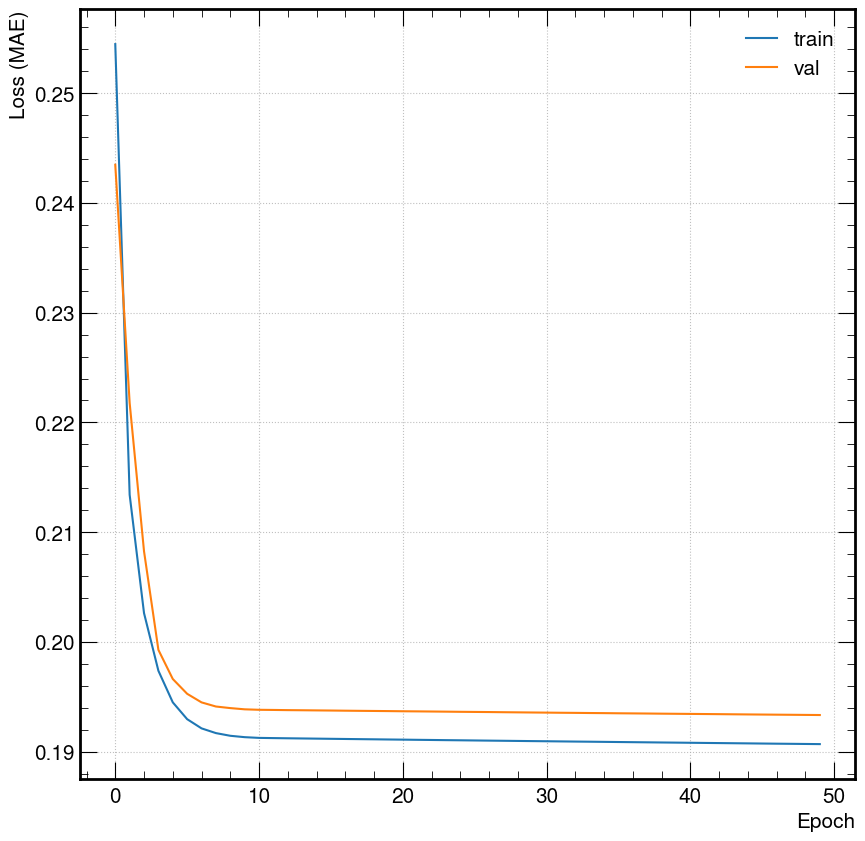

In [5]:
npz_unpacked_loss = np.load(path_to_result + "/losses.npz")

train_loss = npz_unpacked_loss['training']
val_loss = npz_unpacked_loss['validation']

val_mean_loss=np.mean(val_loss, axis=1)
train_mean_loss=np.mean(train_loss, axis=1)

plt.plot(train_mean_loss,label='train')

plt.plot(val_mean_loss, label='val')
plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss (MAE)", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid()

In [6]:
# Returns a sorted array of unique target energies
energy_bins = np.unique(np.round(targets_energy).astype(int))
print(energy_bins)

[  1   2   4   5   8  12  17  25  35  51  73 104 150]


In [7]:
eta_bins = [(3.2, 3.4), (3.4,3.6), (3.6,3.8),(3.8, 4)]
truth_eta = -1*np.log(np.tan(targets_theta/2))

/tmp/ipykernel_1396536/2814570774.py:2: RuntimeWarning: invalid value encountered in log
  truth_eta = -1*np.log(np.tan(targets_theta/2))


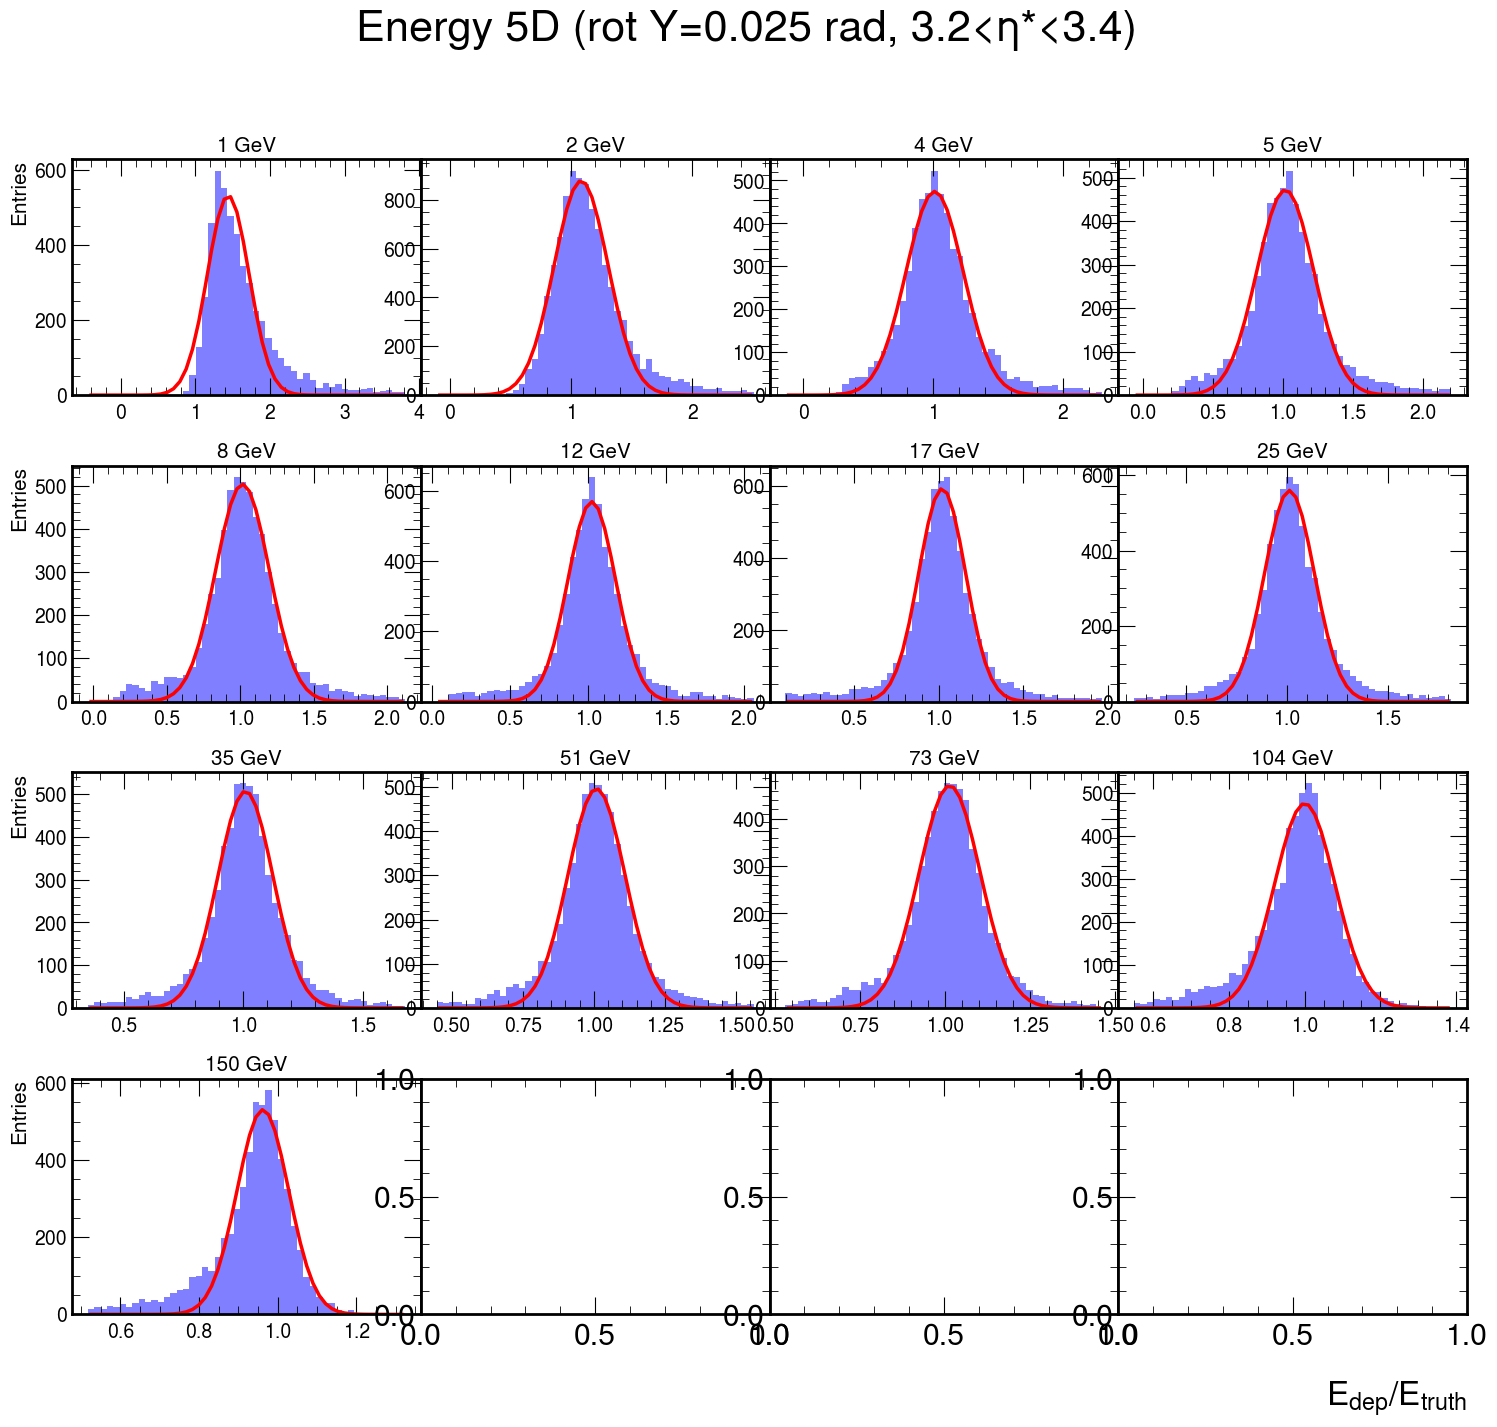

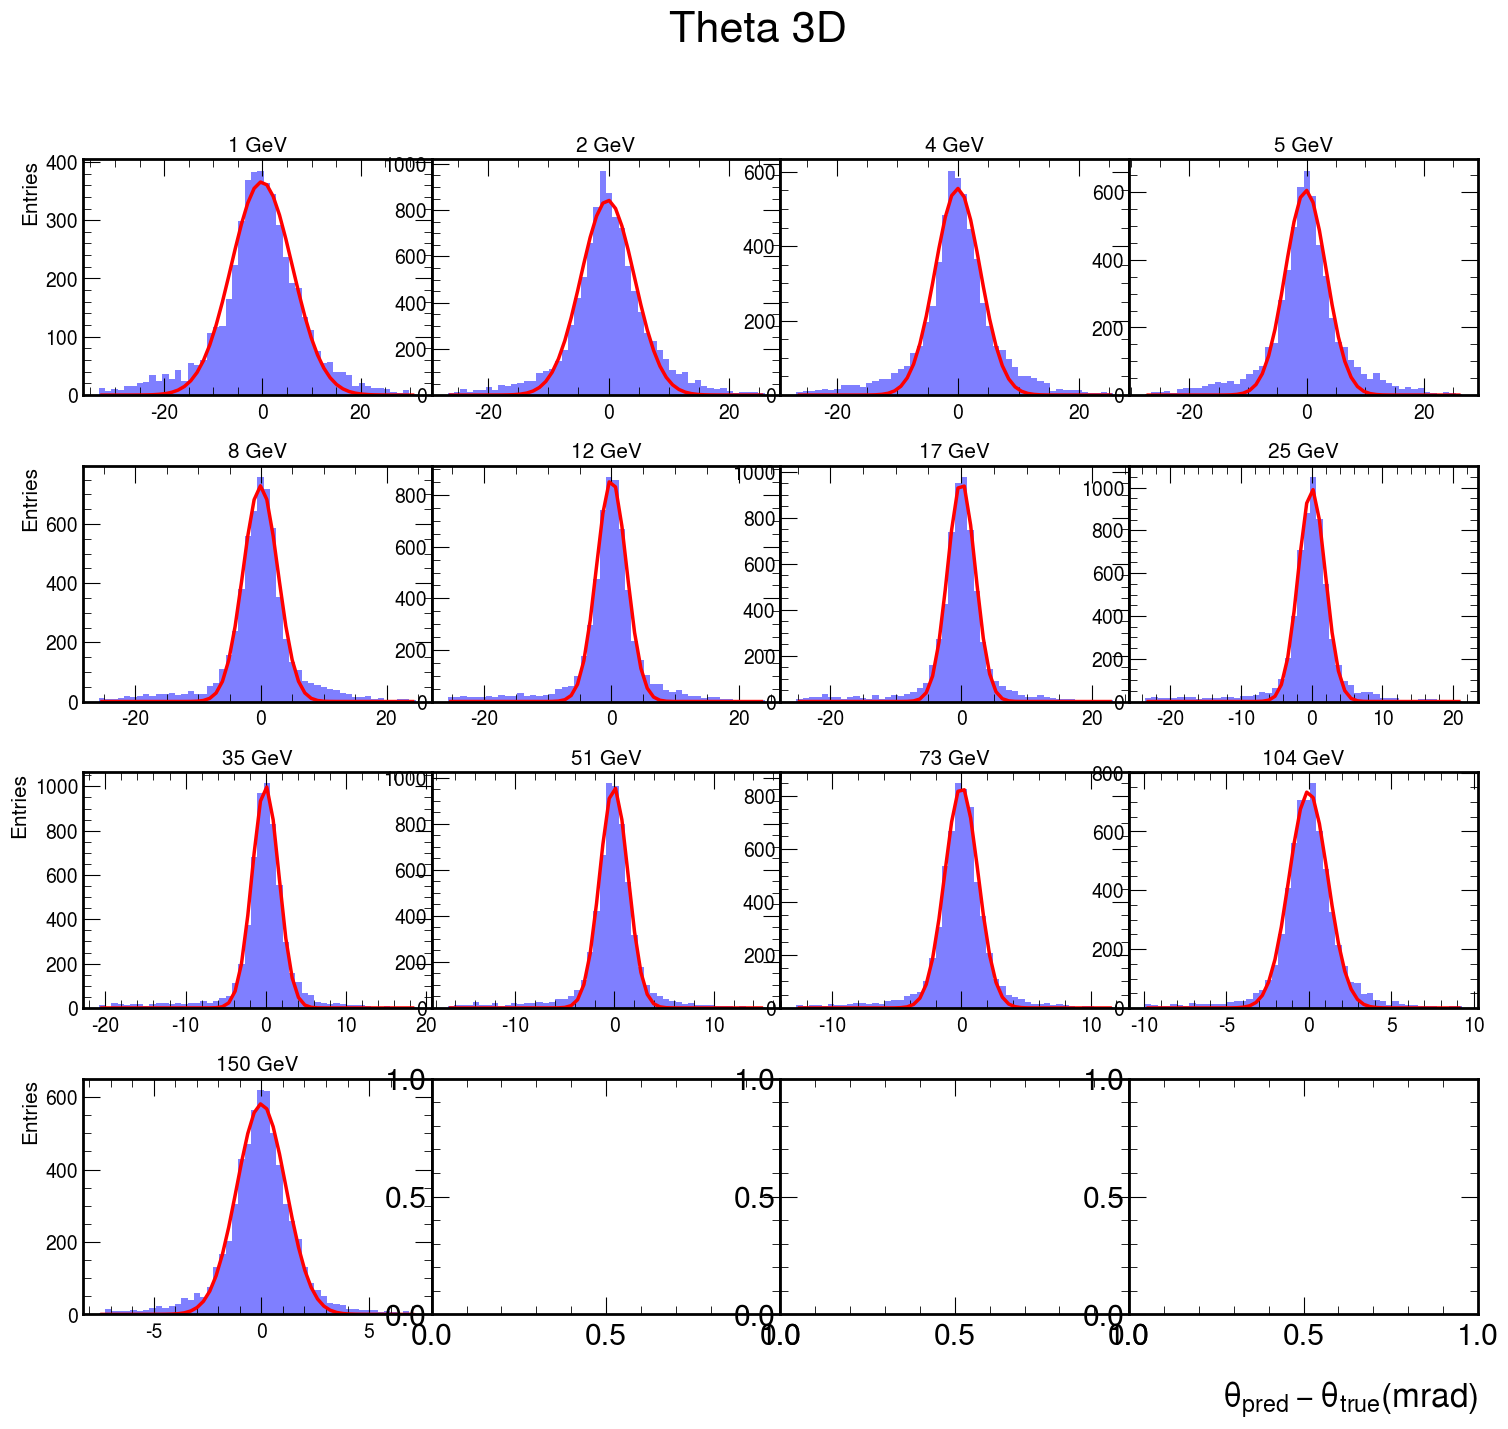

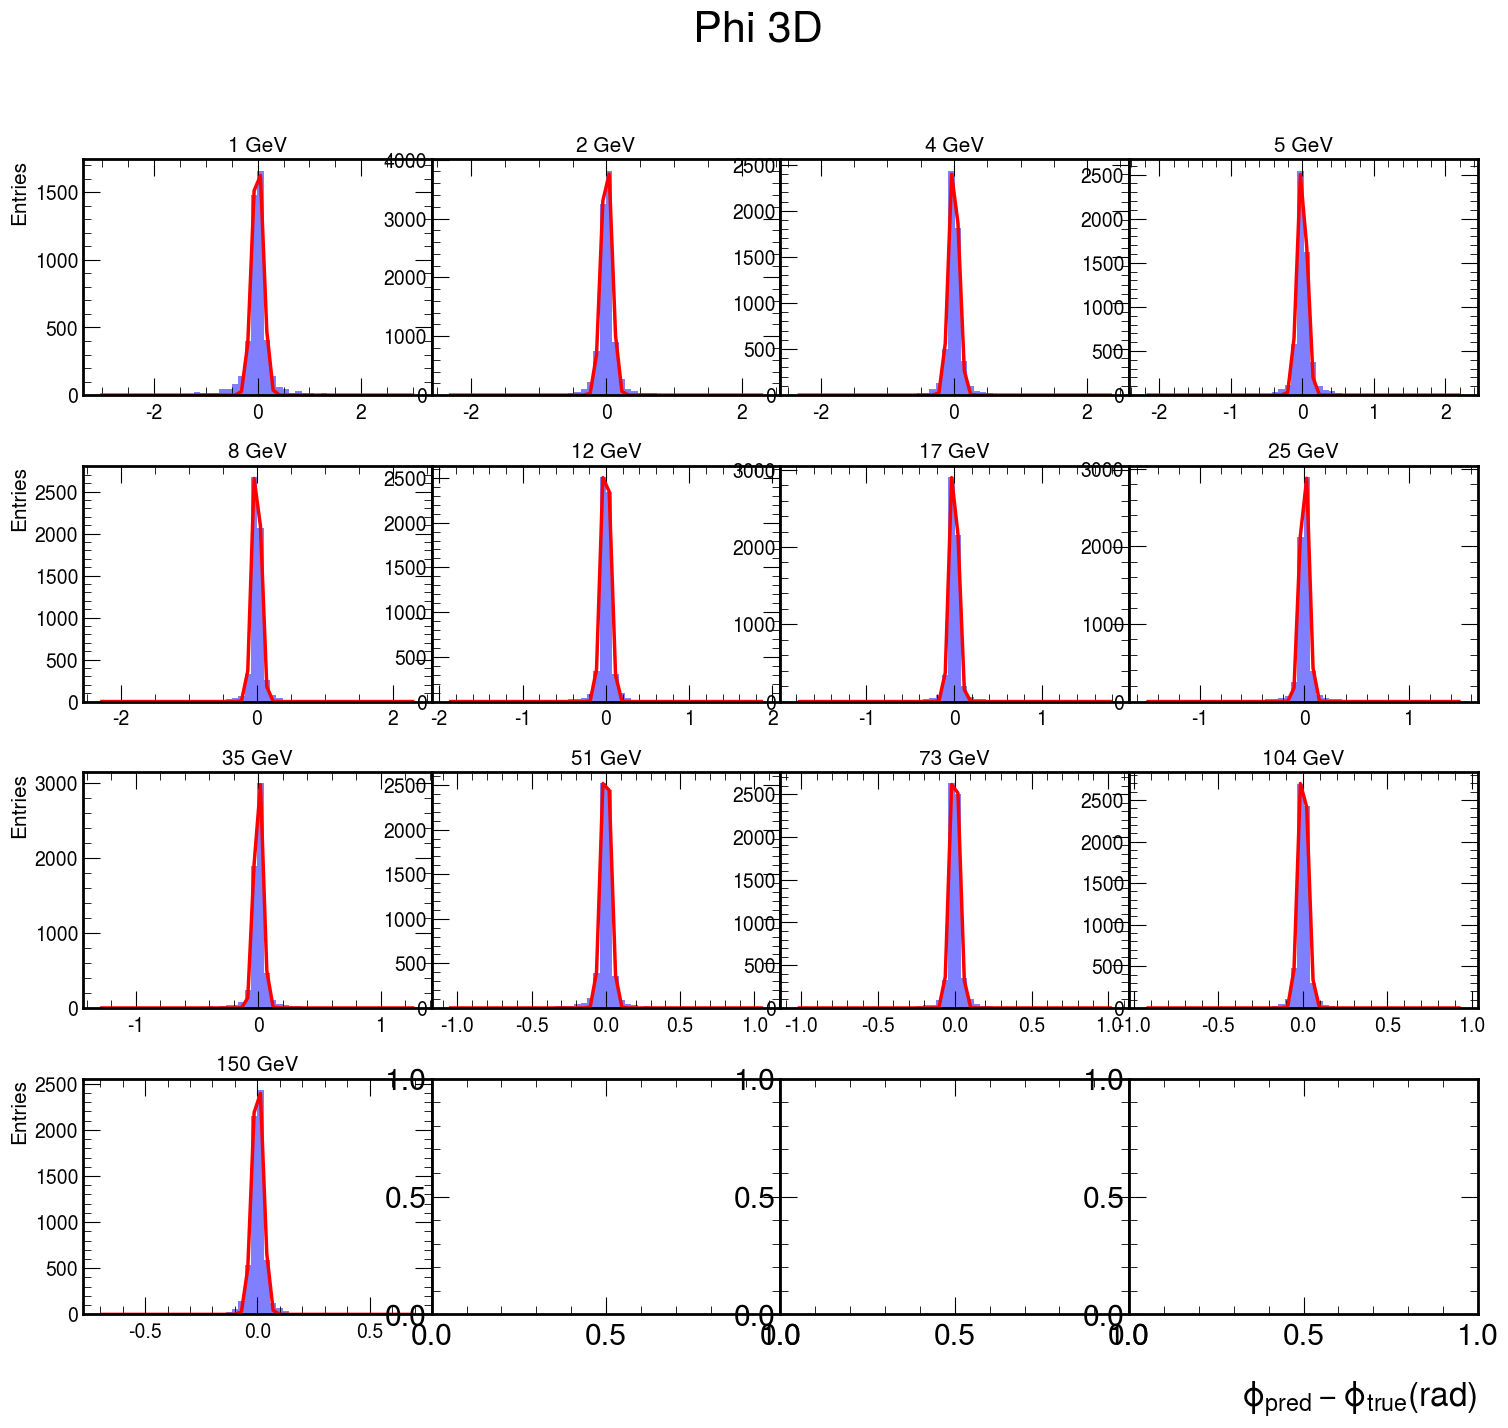

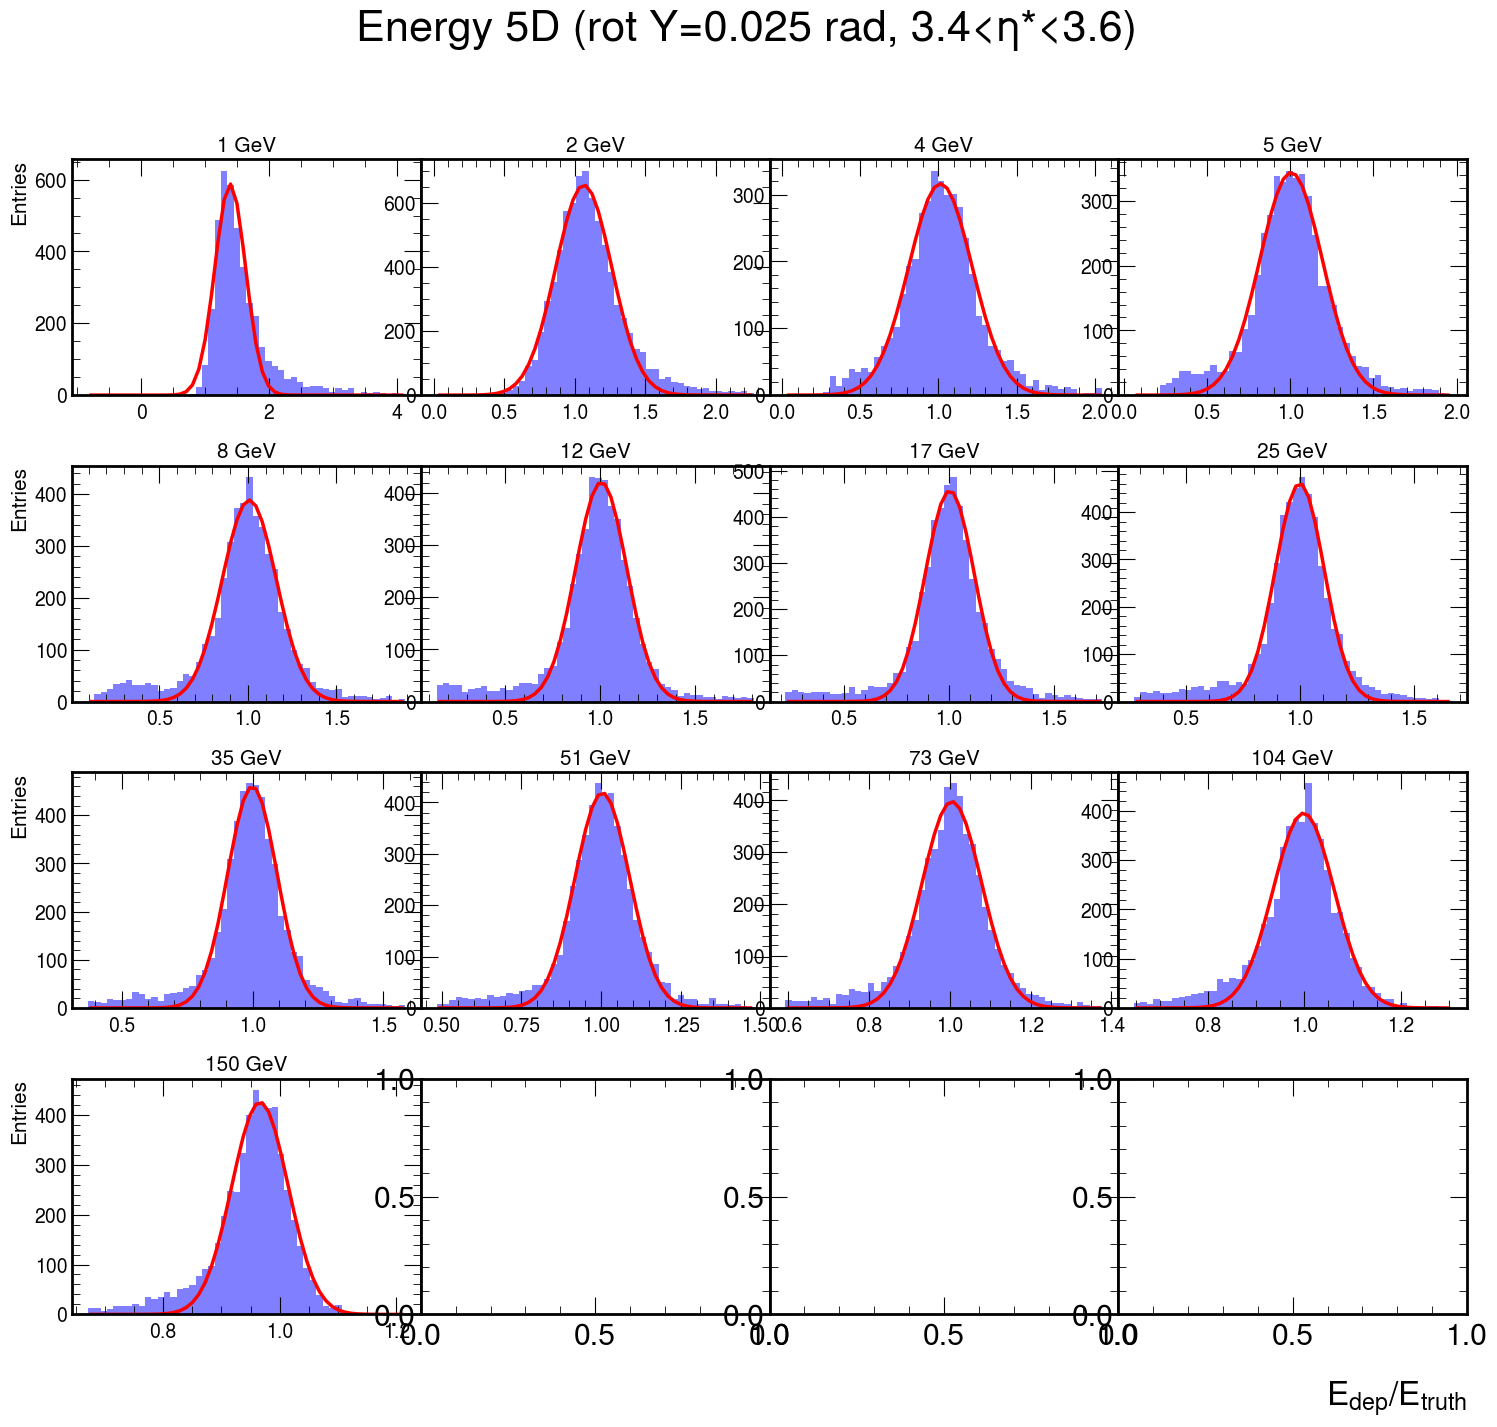

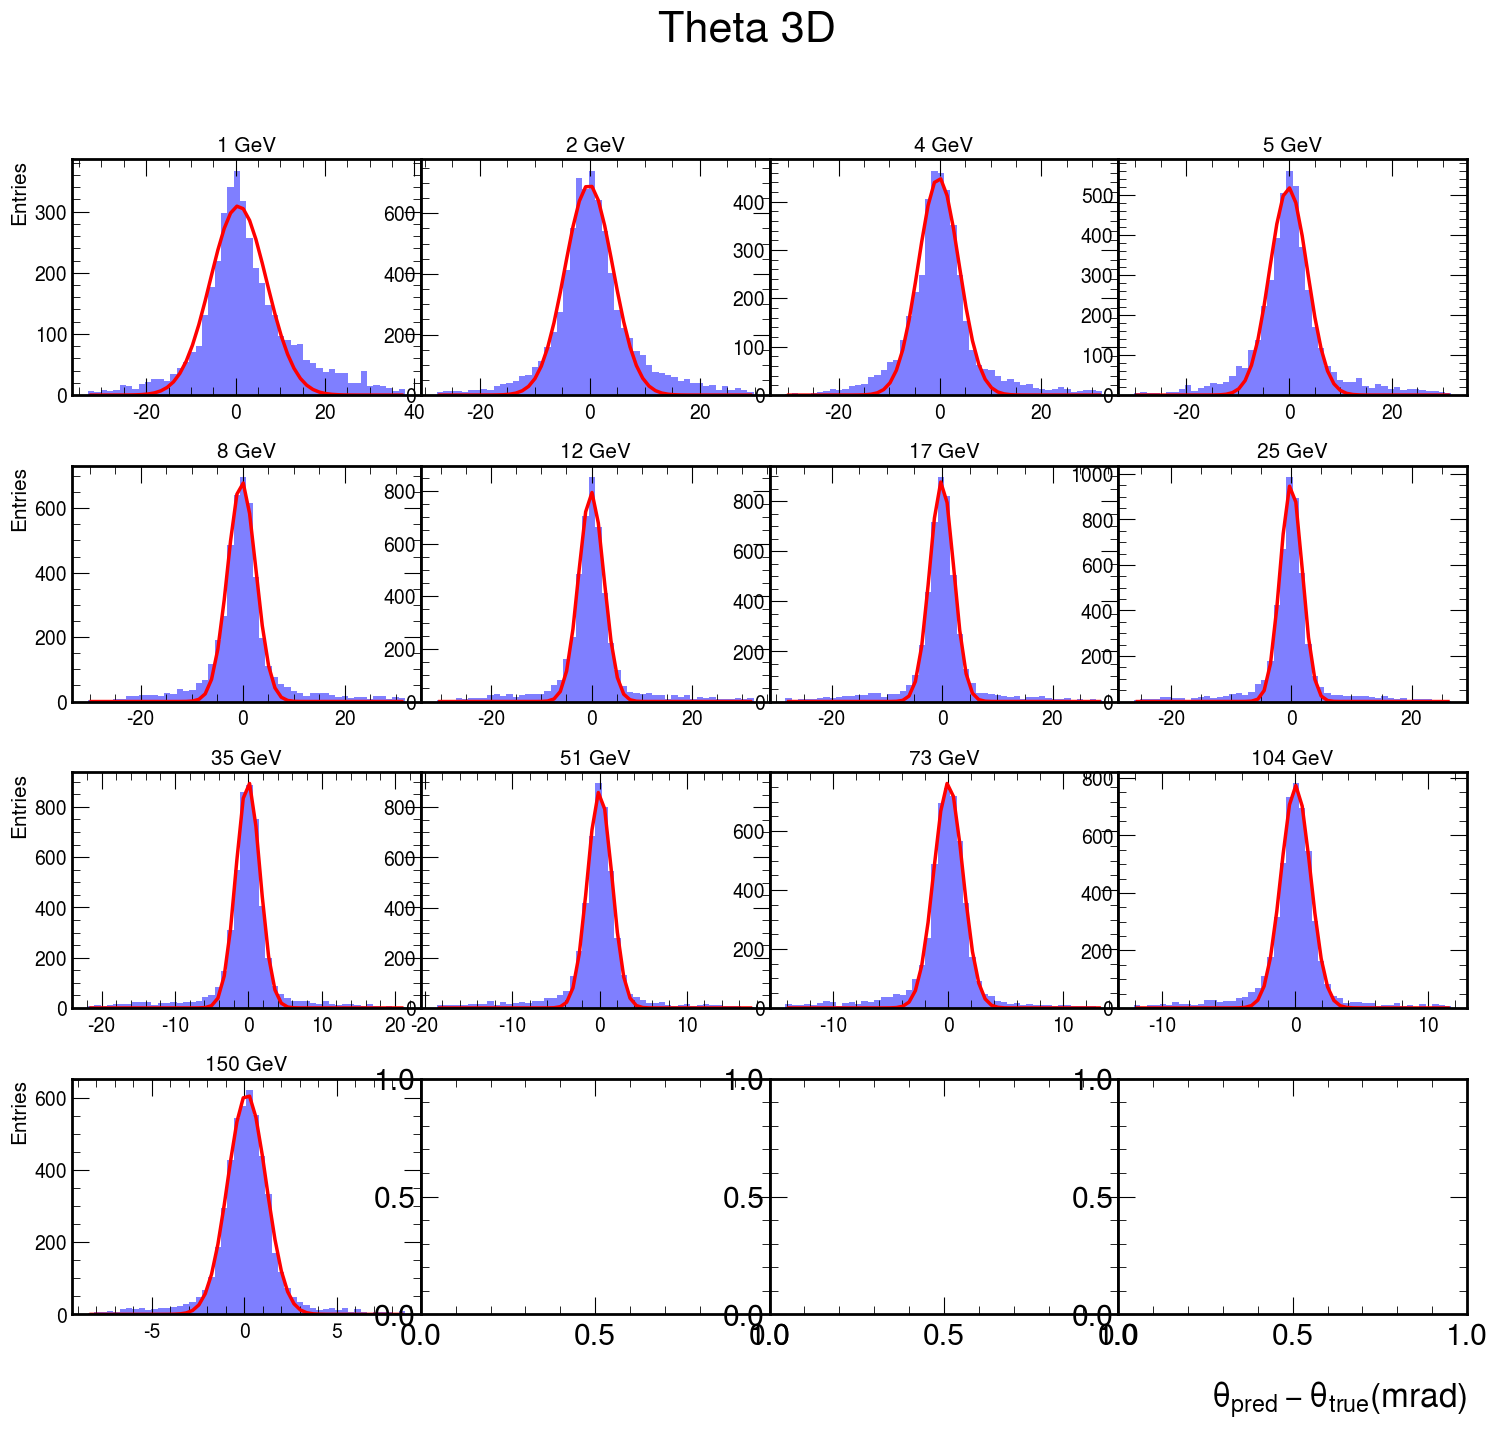

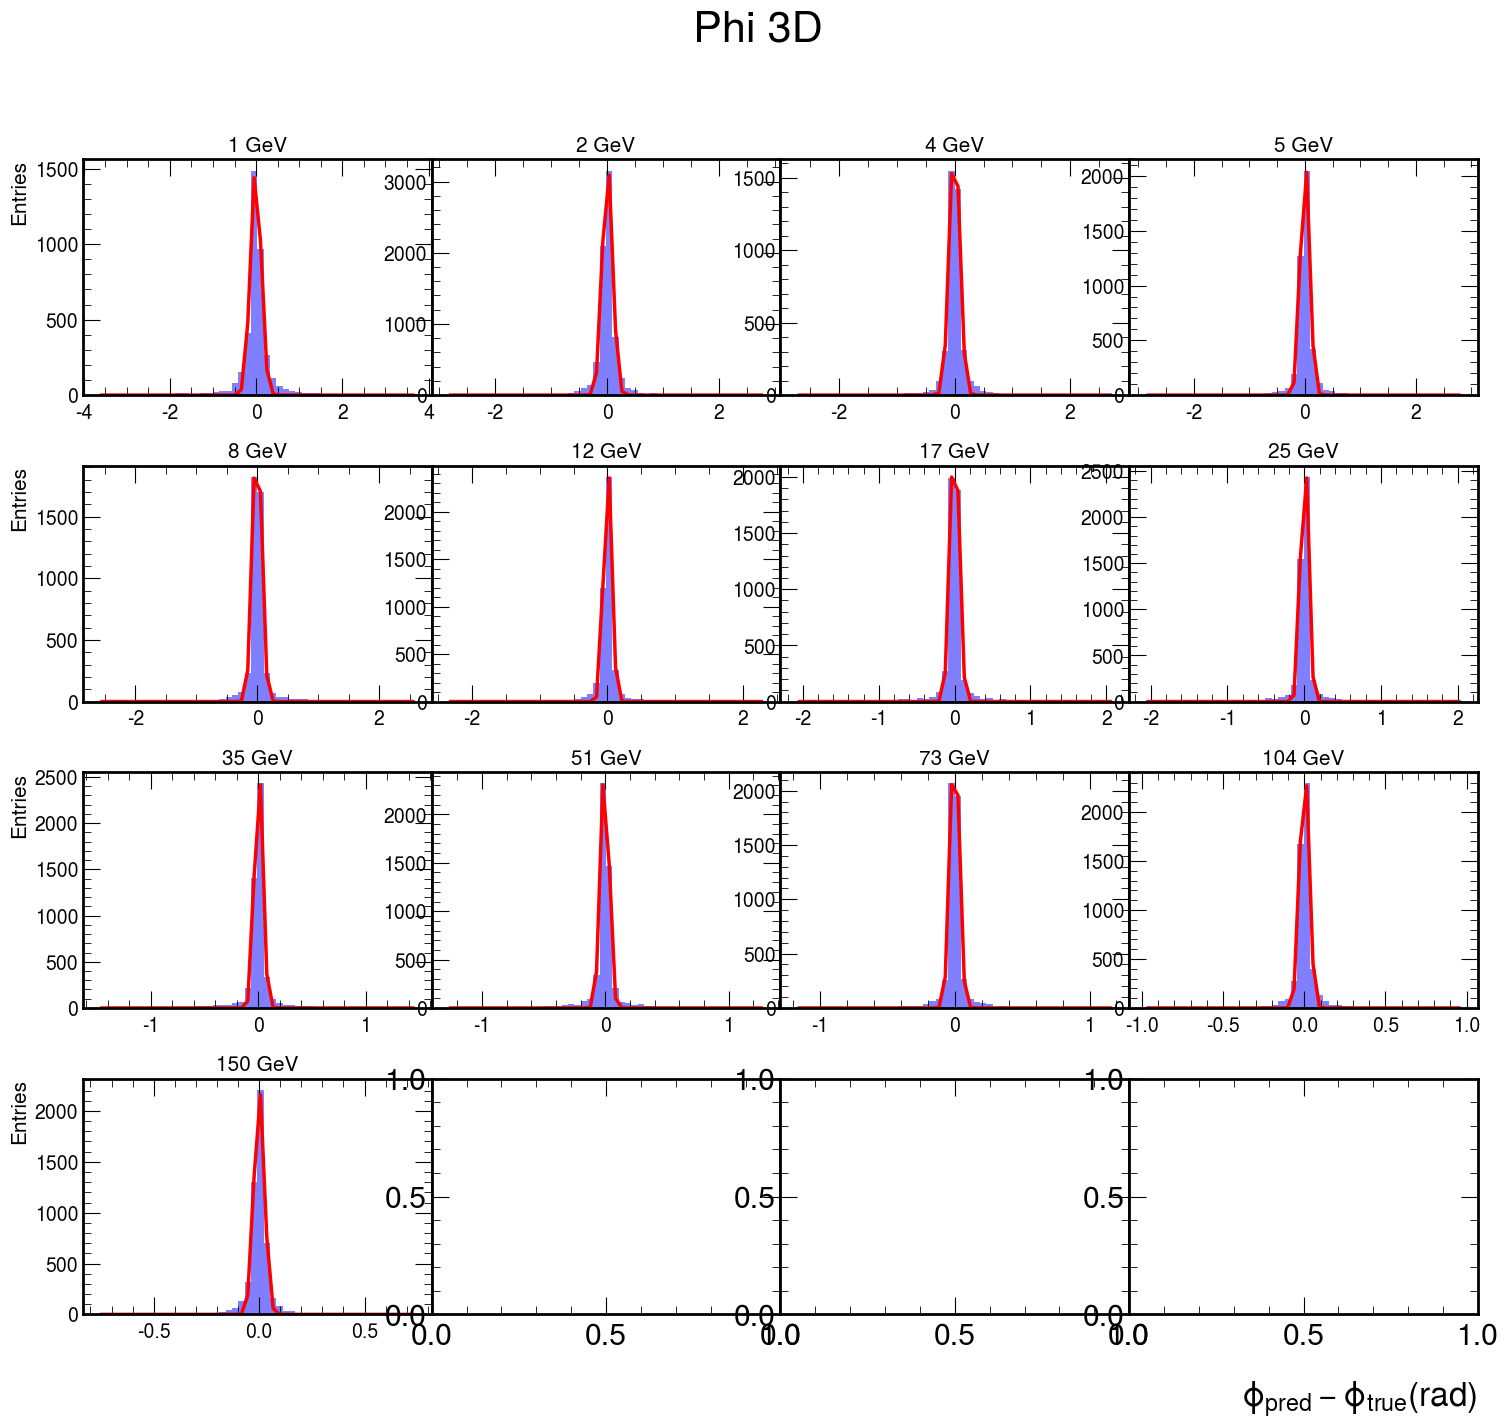

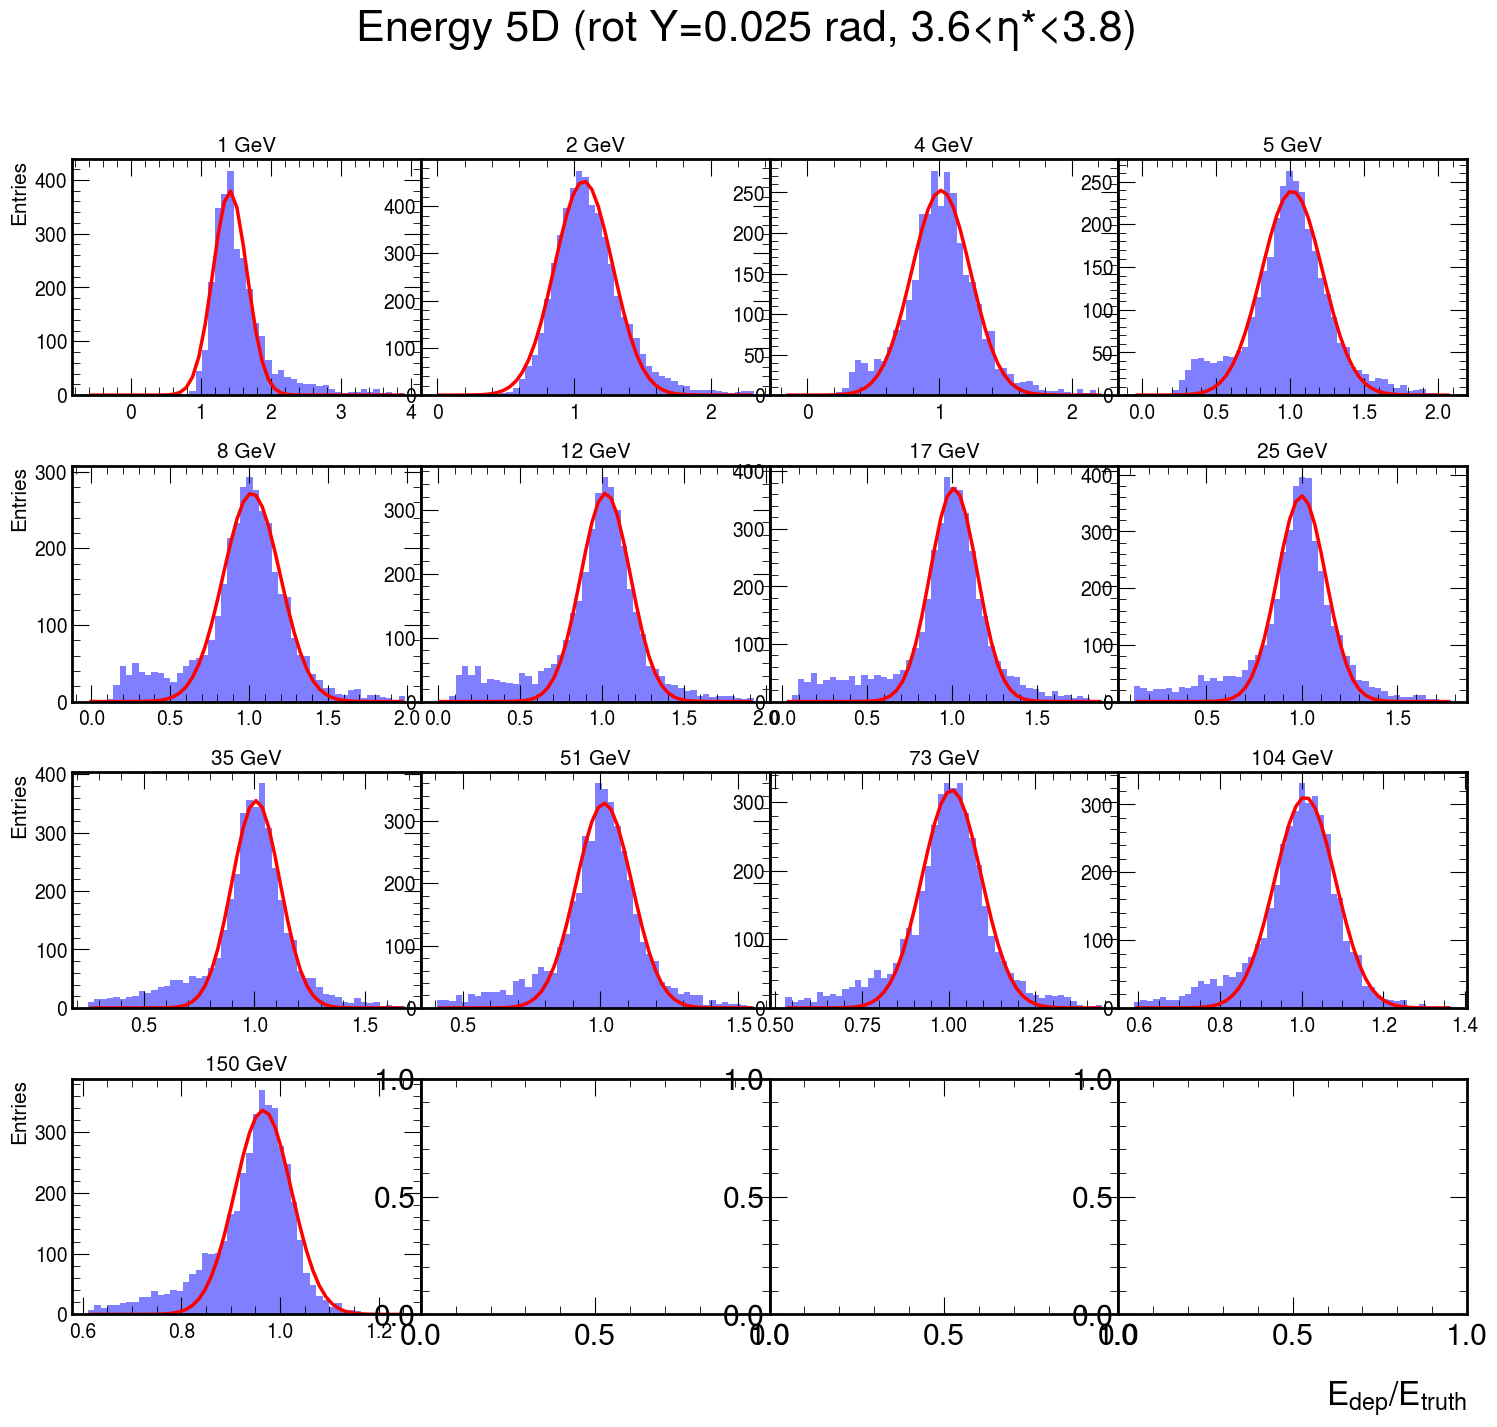

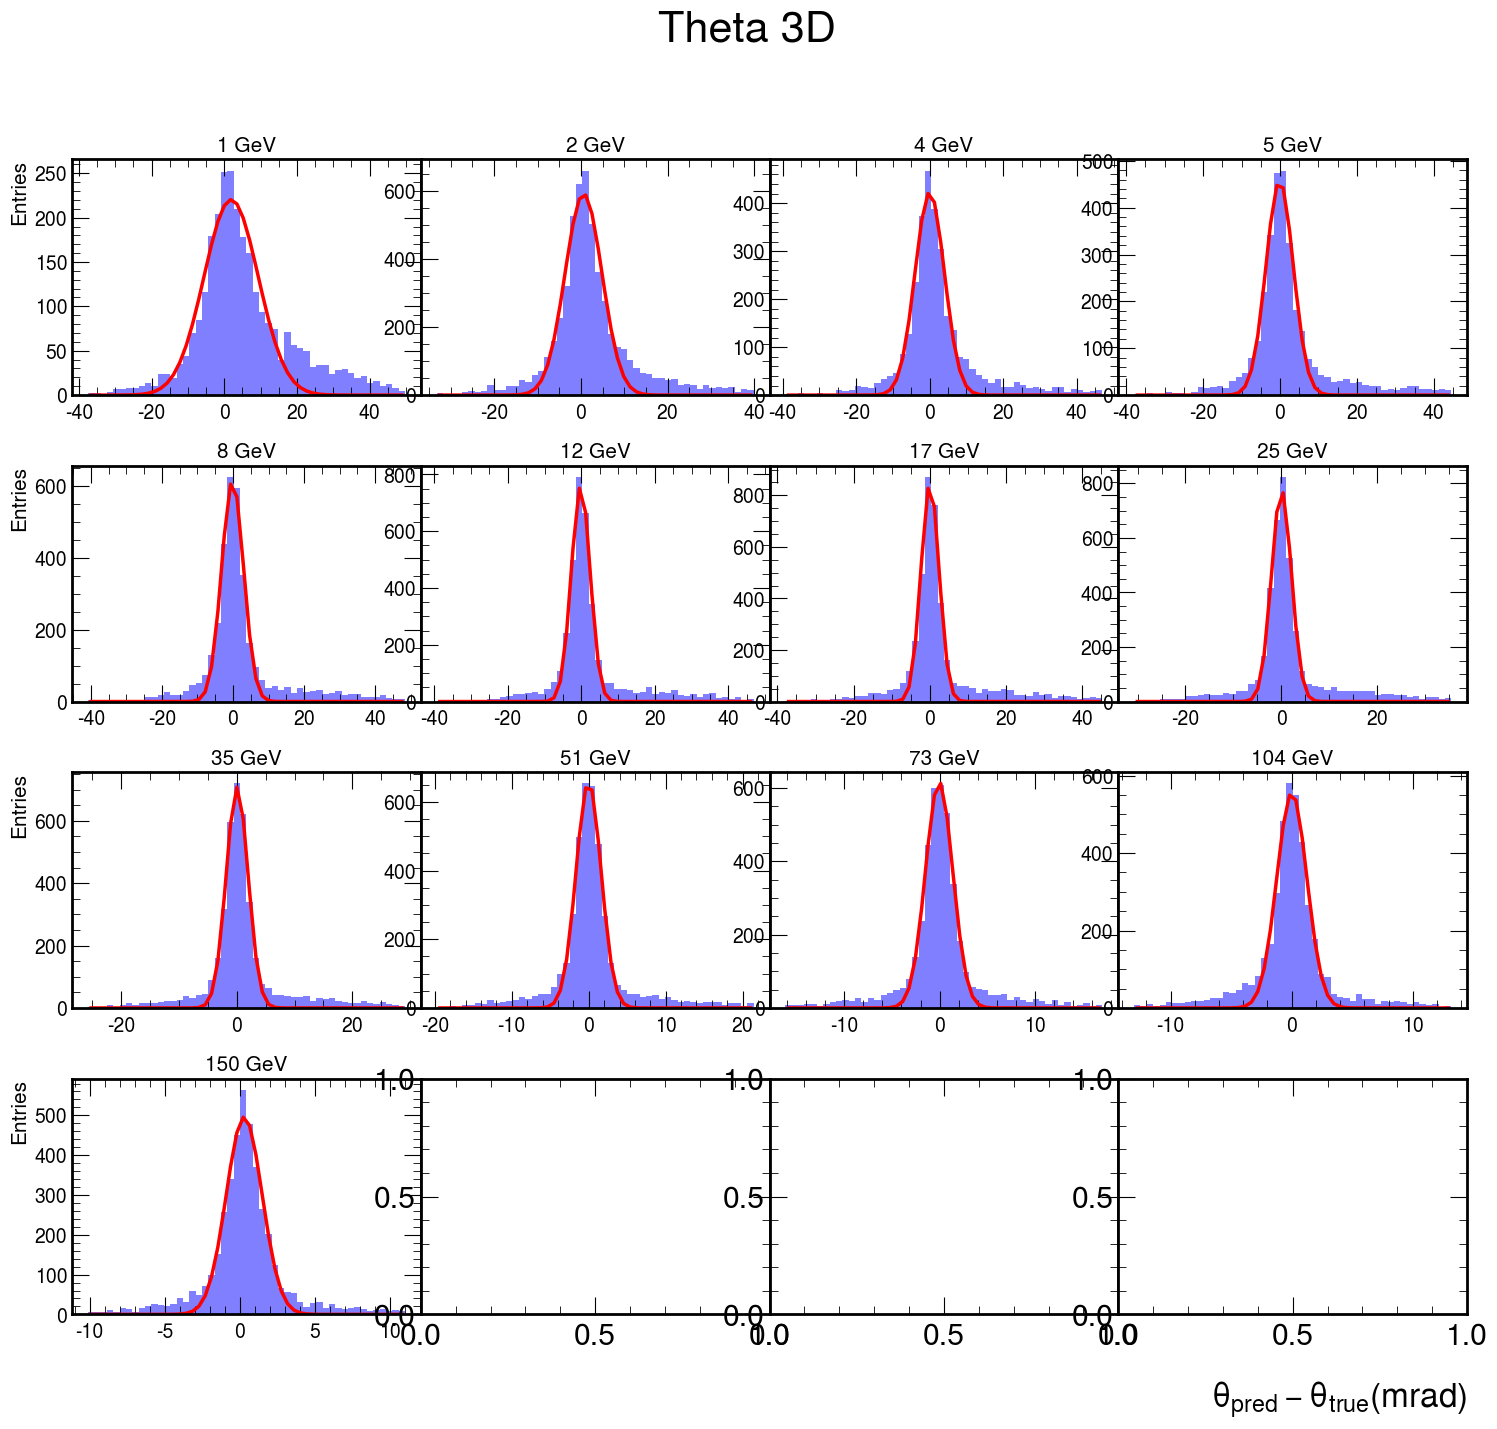

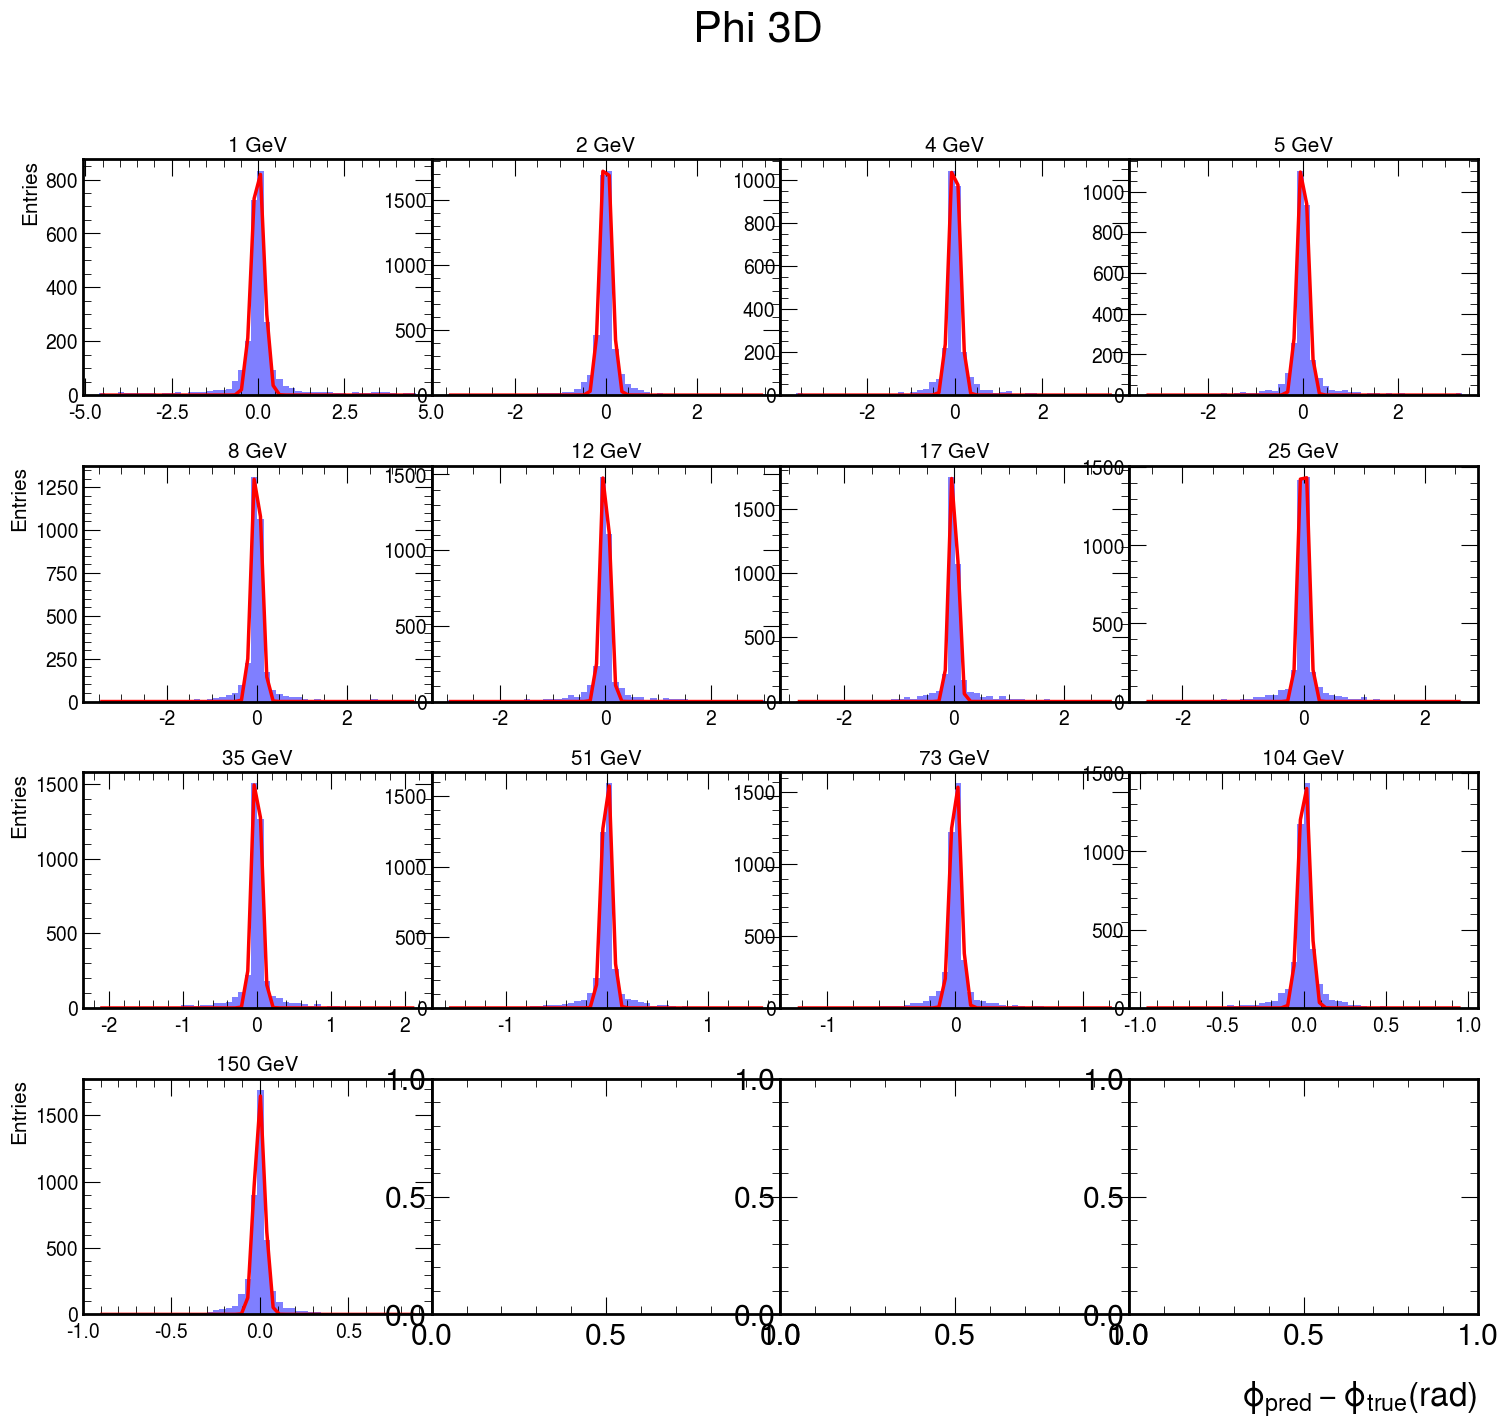

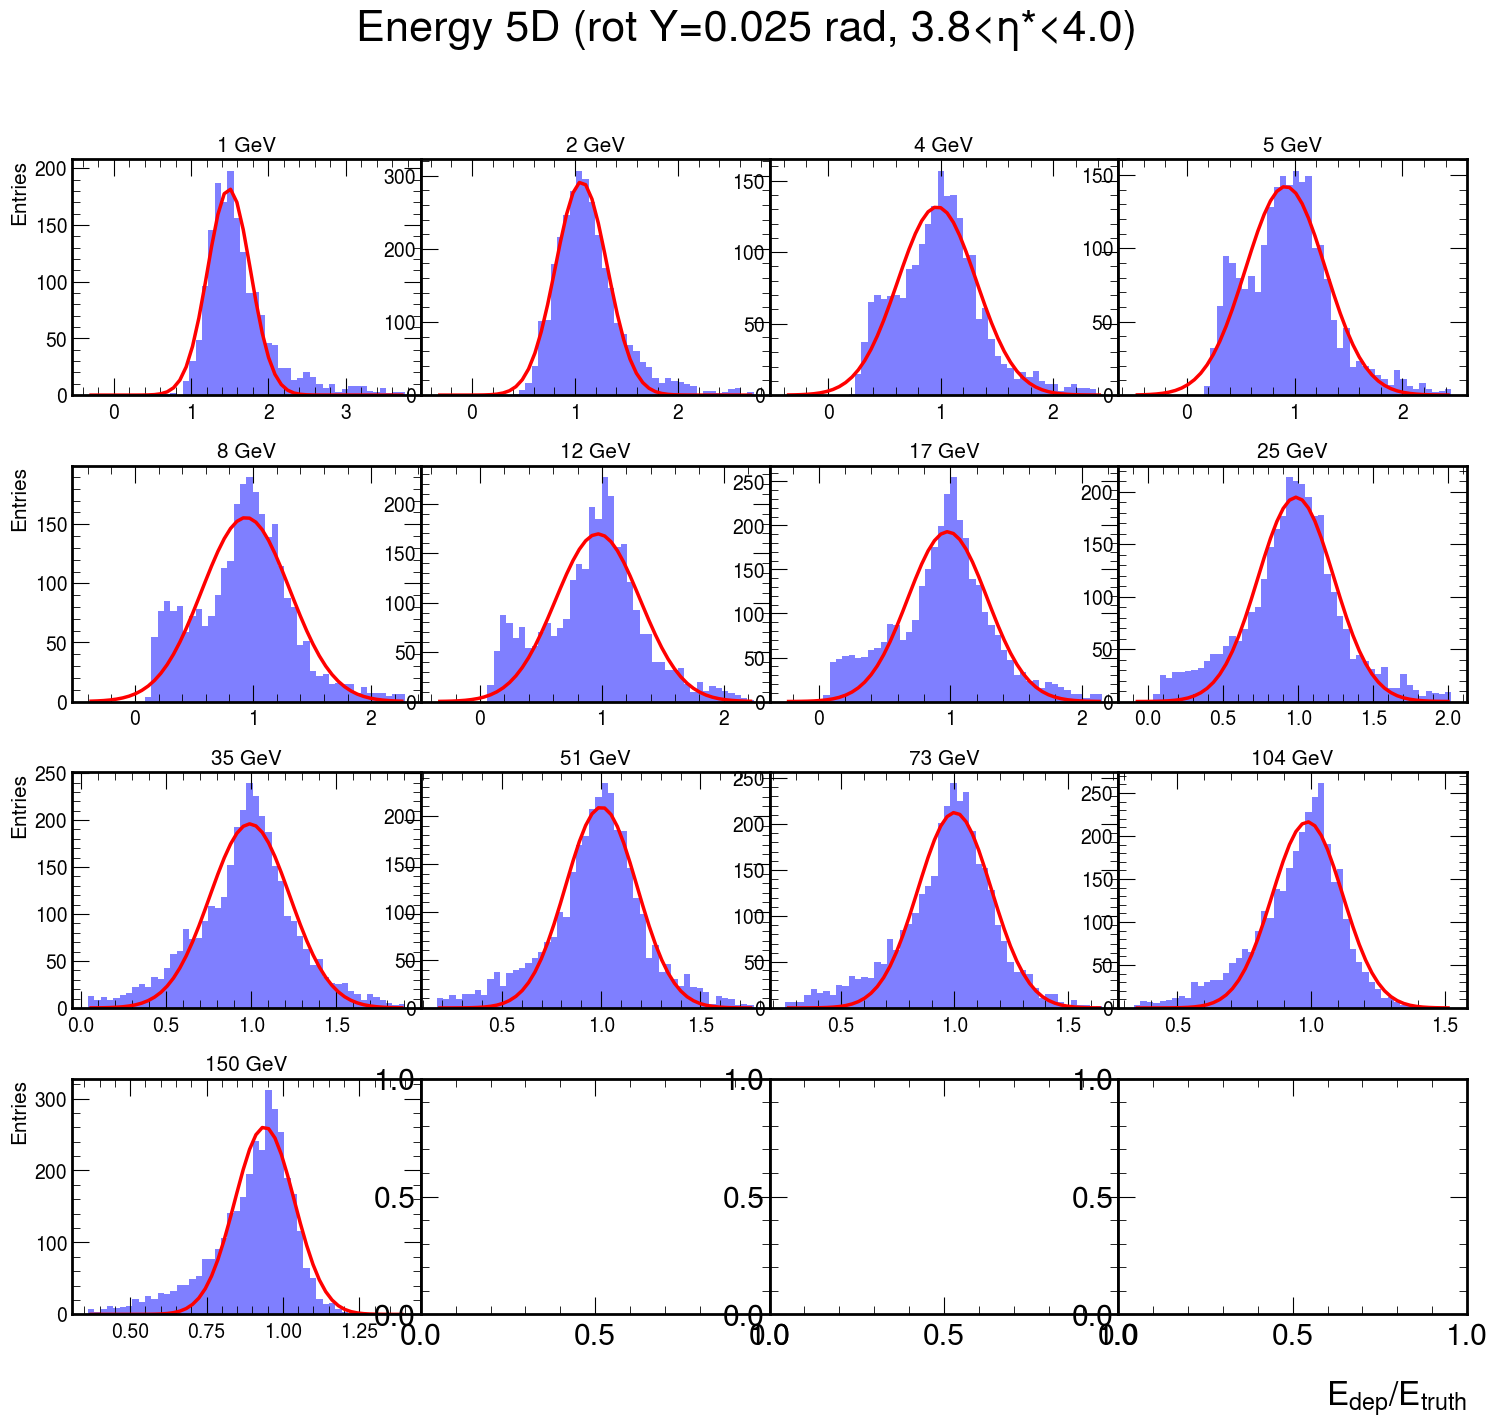

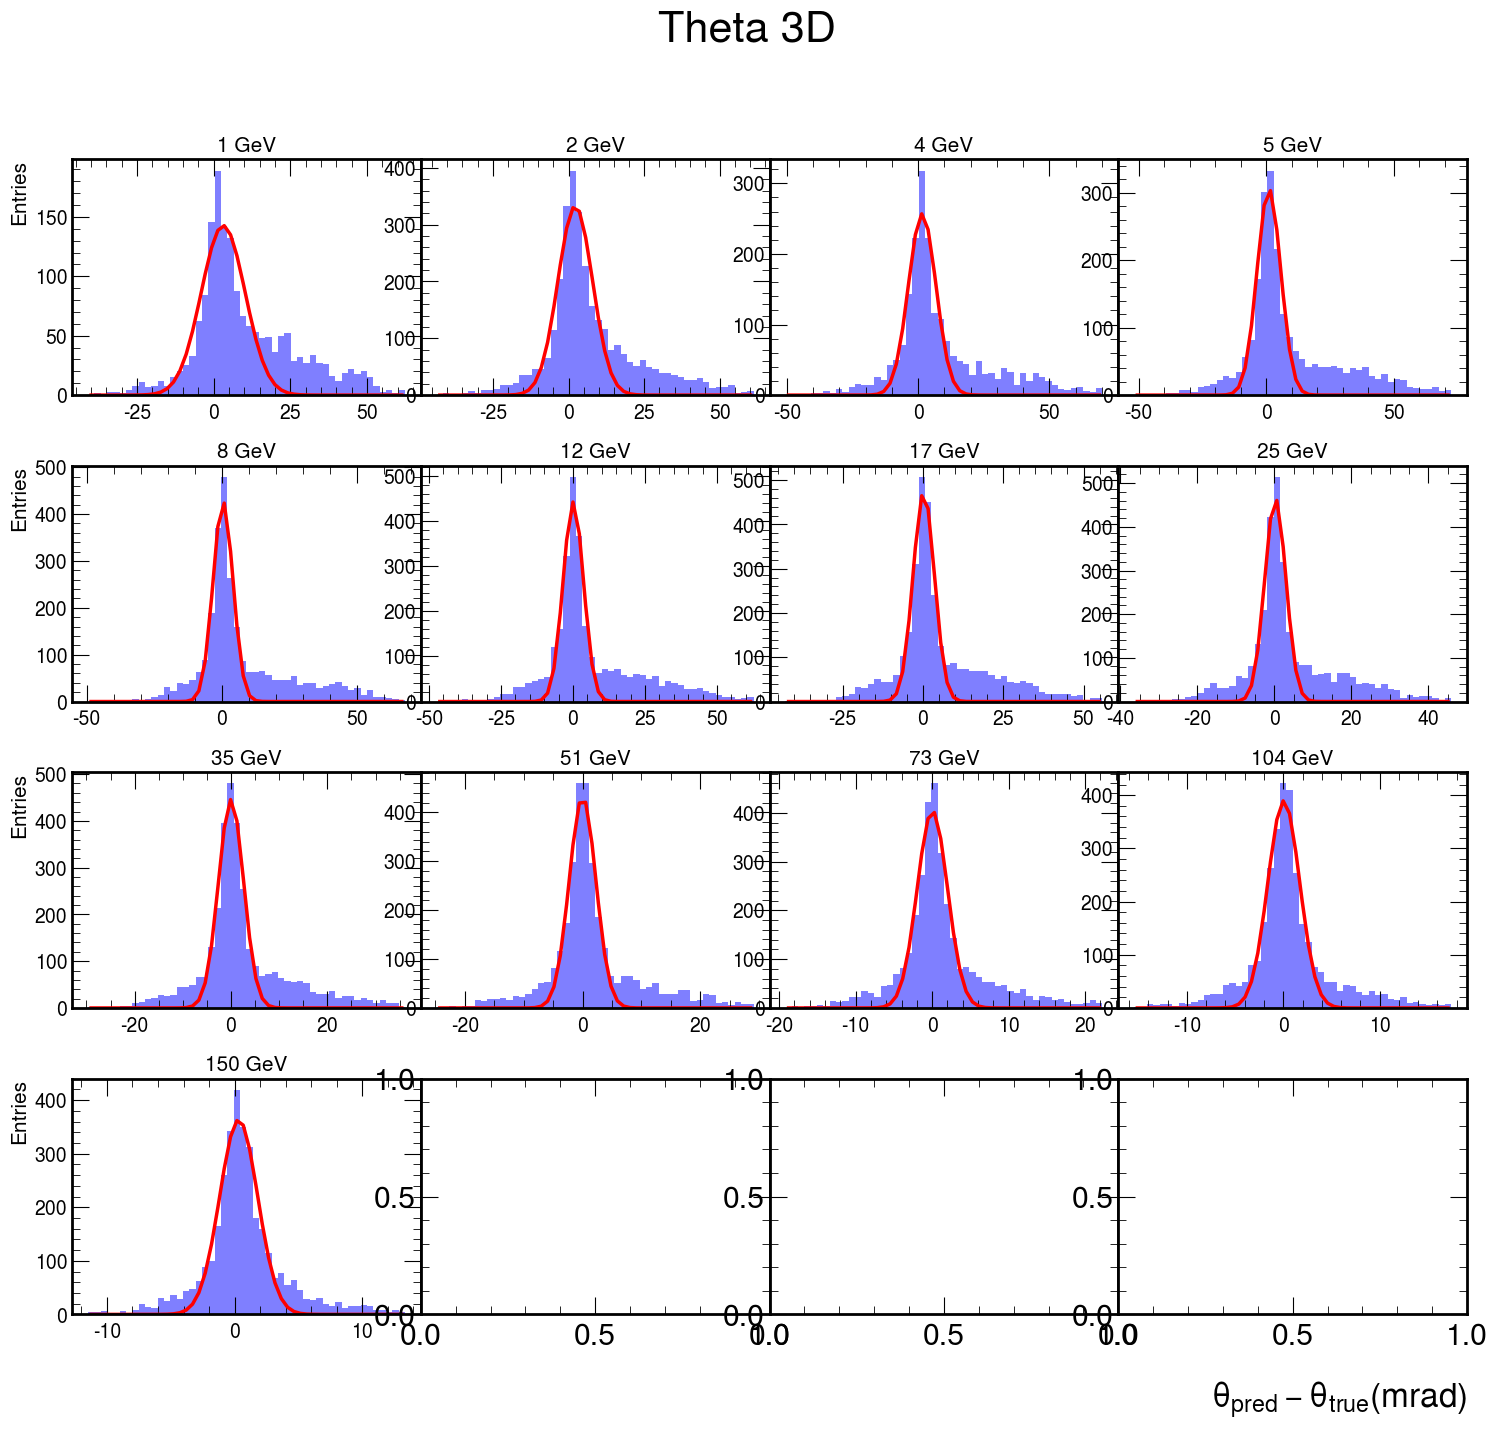

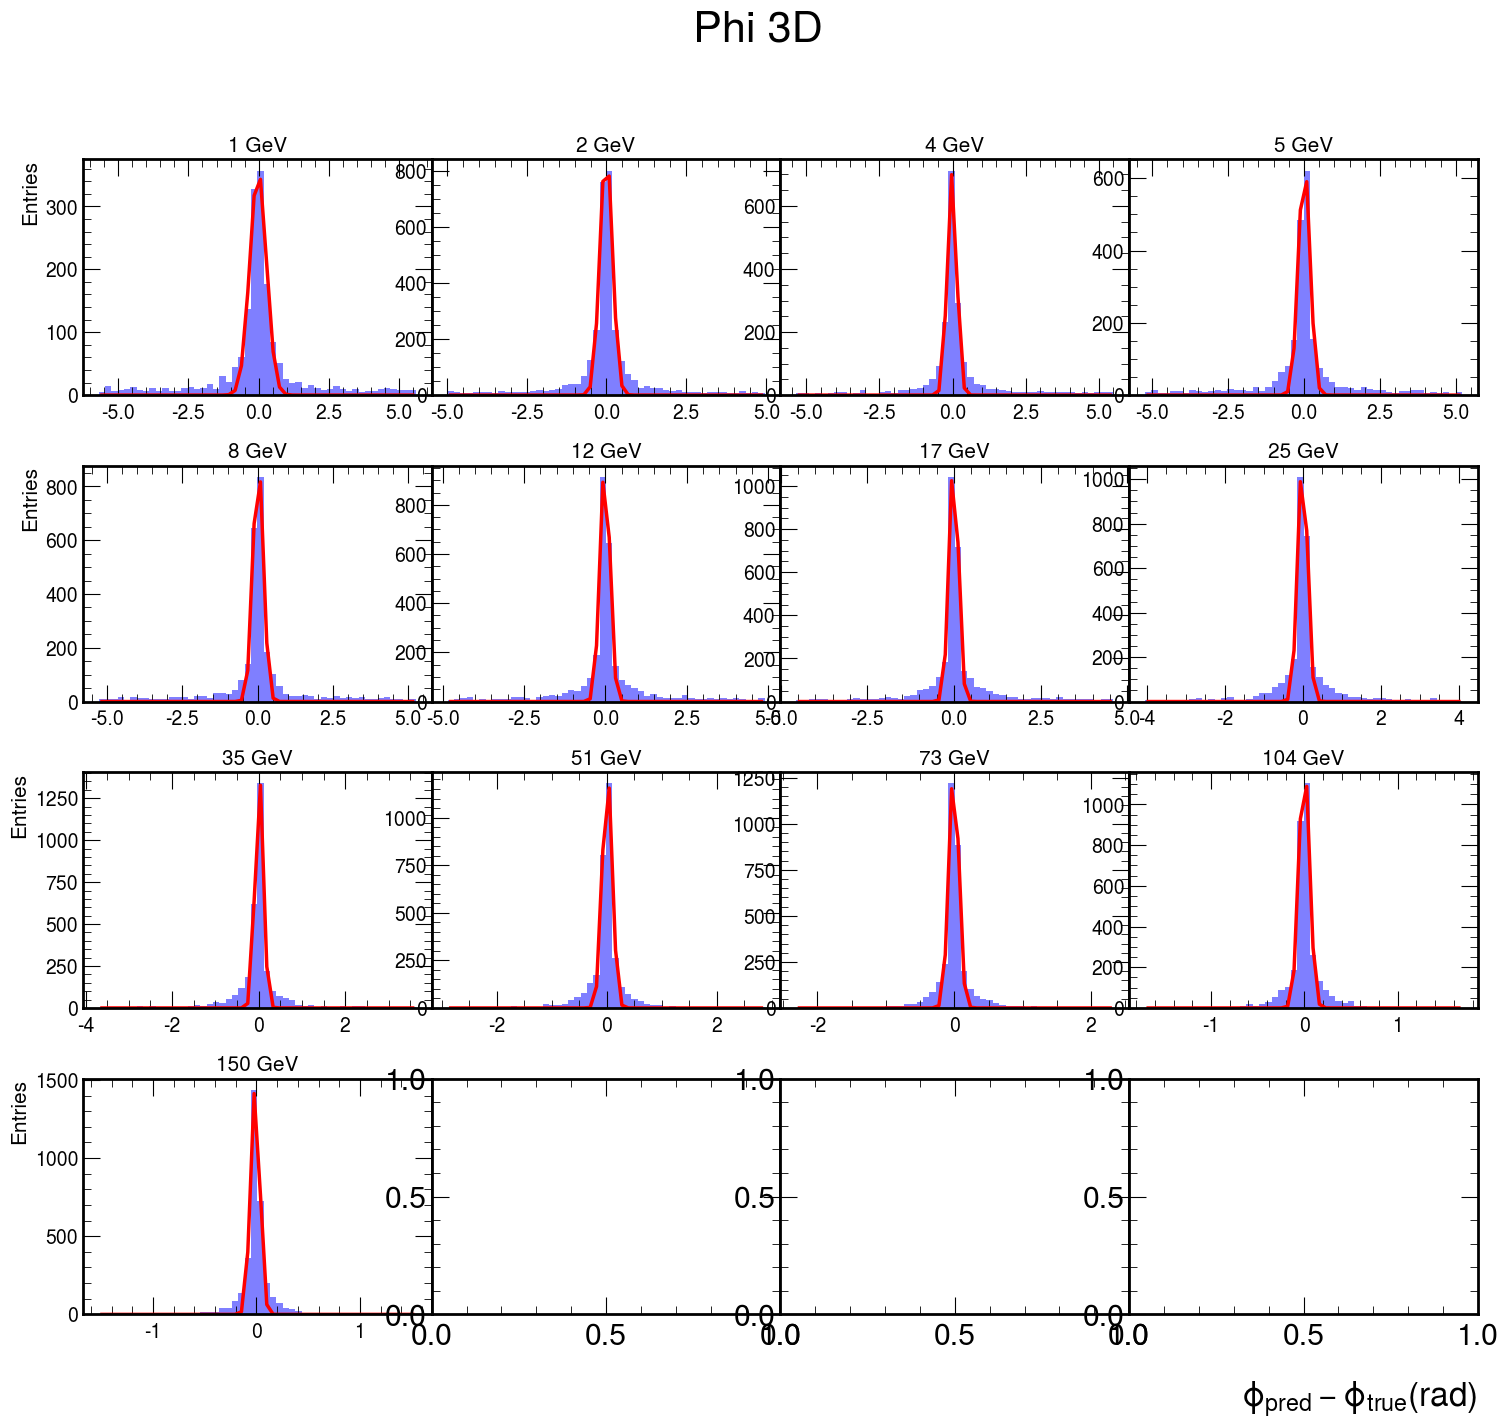

In [8]:
if not already_rotated:
    # build rotated truth eta with SAME indexing as your ML arrays
    if output_dim == '3D':
        truth_eta_rot = rotated_eta_from_theta_phi(targets_theta, targets_phi, angle_rad=0.025)
    elif output_dim == '2D':
        raise ValueError("Need phi to rotate around Y. Run a 3D target or provide phi.")
    else:
        raise ValueError("Rotation requires angular targets.")

    eta_bins = [(3.2, 3.4), (3.4, 3.6), (3.6, 3.8), (3.8, 4.0)]
    eta_truth_energies, eta_energy_resolutions, eta_energy_scales = [], [], []
    eta_theta_resolutions, eta_phi_resolutions = [], []
    for eta_range in eta_bins:
        eta_mask = (truth_eta_rot >= eta_range[0]) & (truth_eta_rot < eta_range[1])

        truth_energies, energy_resolutions, energy_scales, energy_leakage = get_resolutions(
            predictions_energy[eta_mask],
            targets_energy[eta_mask],
            energy_bins,
            nbins=50,
            data_name="energy",
            divide_by_genE=True,
            title=f"Energy 5D (rot Y=0.025 rad, {eta_range[0]}<η*<{eta_range[1]})"
        )

        eta_truth_energies.append(truth_energies)
        eta_energy_resolutions.append(energy_resolutions)
        eta_energy_scales.append(energy_scales)
        
        theta_predicted_truth_difference = predictions_theta[eta_mask] - targets_theta[eta_mask]
        _, theta_resolutions, _, _ = get_resolutions(theta_predicted_truth_difference,
                                                     targets_energy[eta_mask],
                                                     energy_bins,
                                                     nbins = 50,
                                                     data_name = "theta",
                                                     title="Theta 3D")
        
        eta_theta_resolutions.append(theta_resolutions)
        
        phi_predicted_truth_difference = predictions_phi[eta_mask] - targets_phi[eta_mask]
        _, phi_resolutions, _, _ = get_resolutions(phi_predicted_truth_difference,
                                                   targets_energy[eta_mask],
                                                   energy_bins,
                                                   nbins = 50,
                                                   data_name = "phi",
                                                   title="Phi 3D")
        
        eta_phi_resolutions.append(phi_resolutions)
        
else:
    eta_truth_energies, eta_energy_resolutions, eta_energy_scales = [], [], []
    eta_theta_resolutions, eta_phi_resolutions = [], []
    for eta_range in eta_bins:
        eta_mask = (truth_eta>=eta_range[0]) & (truth_eta<eta_range[1])
        truth_energies, energy_resolutions, energy_scales, energy_leakage = get_resolutions(predictions_energy[eta_mask],
                                                                                            targets_energy[eta_mask],
                                                                                            energy_bins,
                                                                                            nbins = 50,
                                                                                            data_name = "energy",
                                                                                            divide_by_genE = True,
                                                                                            title="Energy 3D")
        eta_truth_energies.append(truth_energies)
        eta_energy_resolutions.append(energy_resolutions)
        eta_energy_scales.append(energy_scales)
        
        theta_predicted_truth_difference = predictions_theta[eta_mask] - targets_theta[eta_mask]
        _, theta_resolutions, _, _ = get_resolutions(theta_predicted_truth_difference,
                                                     targets_energy[eta_mask],
                                                     energy_bins,
                                                     nbins = 50,
                                                     data_name = "theta",
                                                     title="Theta 3D")
        
        eta_theta_resolutions.append(theta_resolutions)
        
        phi_predicted_truth_difference = predictions_phi[eta_mask] - targets_phi[eta_mask]
        _, phi_resolutions, _, _ = get_resolutions(phi_predicted_truth_difference,
                                                   targets_energy[eta_mask],
                                                   energy_bins,
                                                   nbins = 50,
                                                   data_name = "phi",
                                                   title="Phi 3D")
        
        eta_phi_resolutions.append(phi_resolutions)

In [9]:
def resolution_eqn(x, a, c):
    return np.sqrt((a/np.sqrt(x))**2 +c*c)

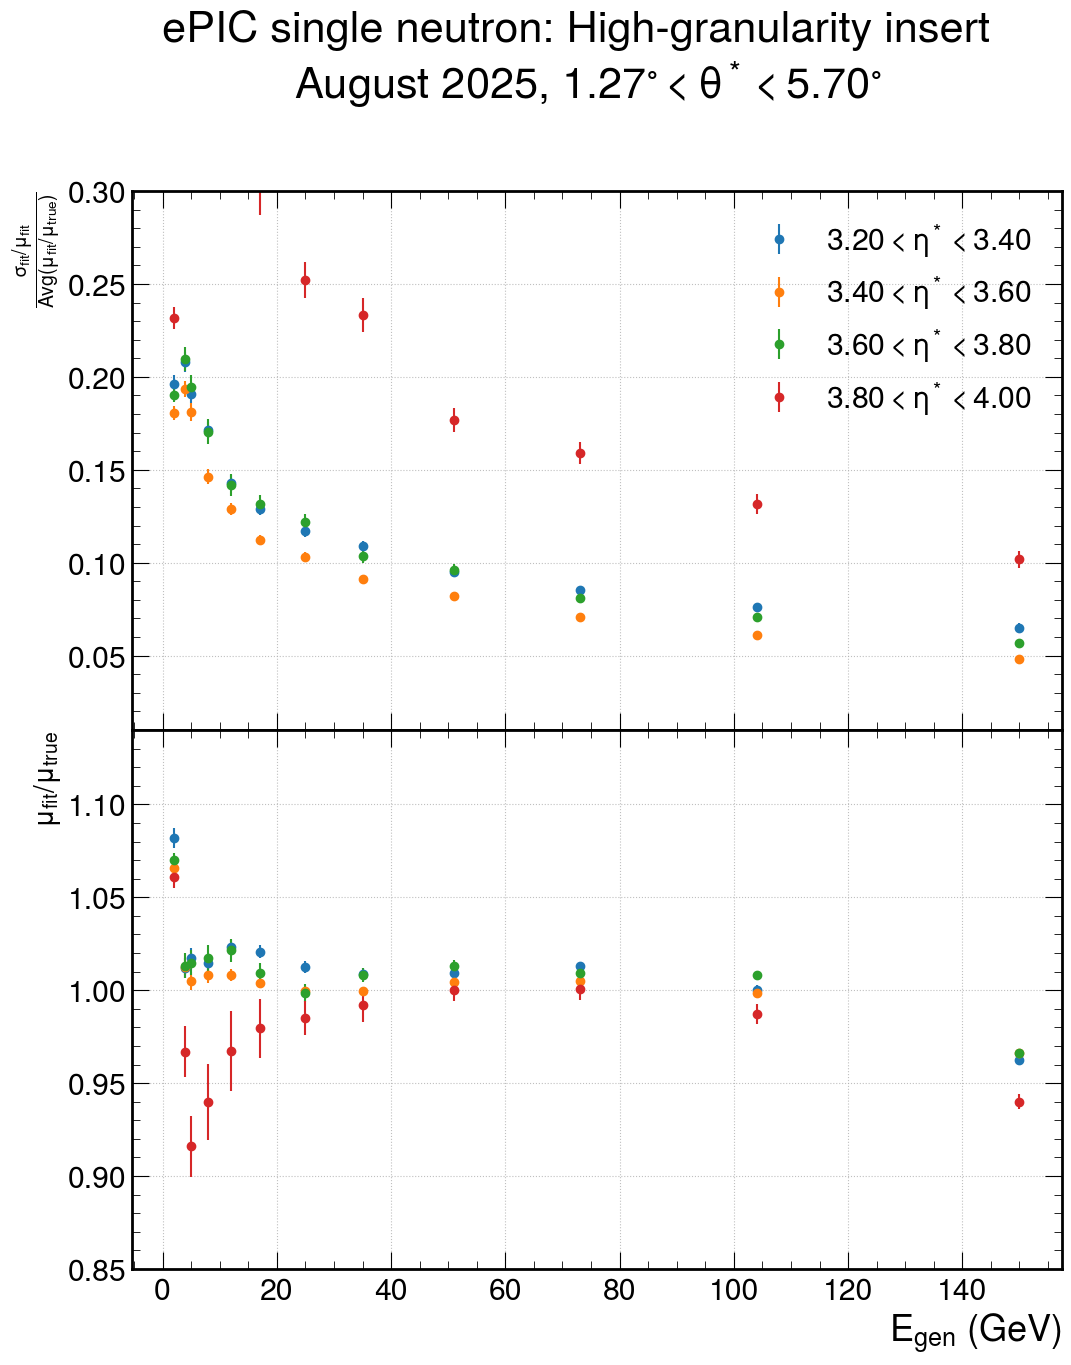

In [10]:
fig = plt.figure(figsize=(12,14))
fig.set_facecolor('w')
gs = fig.add_gridspec(2, hspace=0)
axs = gs.subplots(sharex=True, sharey=False)

lower_energy_lim = 2
for i, eta_range in enumerate(eta_bins):
    truth_energy = eta_truth_energies[i]
    energy_mask = truth_energy>=lower_energy_lim
    energy_resolution = eta_energy_resolutions[i][0]
    energy_resolution_error = eta_energy_resolutions[i][1]
    energy_scale = eta_energy_scales[i][0]
    energy_scale_error = eta_energy_scales[i][1]
    axs[0].errorbar(truth_energy[energy_mask],
                    np.asarray(energy_resolution)[energy_mask],
                    yerr = np.asarray(energy_resolution_error)[energy_mask],
                    marker='o',
                    linestyle='none',
                    label = f"${eta_range[0]:.2f}<\eta^*<{eta_range[1]:.2f}$")
    axs[0].set_ylabel("$\\frac{\sigma_{fit}/\mu_{fit}}{Avg (\mu_{fit}/\mu_{true})}$",  fontsize=20)
    axs[0].set_ylim(0.01, .3)
    
    axs[1].errorbar(truth_energy[energy_mask],
                    np.asarray(energy_scale)[energy_mask],
                    yerr = np.asarray(energy_scale_error)[energy_mask],
                    marker='o',
                    linestyle='none')
    axs[1].set_ylim(.85, 1.14)

axs[0].legend()
axs[1].set_ylabel("$\mu_{fit}/\mu_{true}$",  fontsize=20)
axs[1].set_xlabel("$E_{gen}$ (GeV)")
axs[0].grid()
axs[1].grid()
if granularity=="high_granularity":
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.01)
    else:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$", y=1.01)
else:
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.01)
    else:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$", y=1.01)

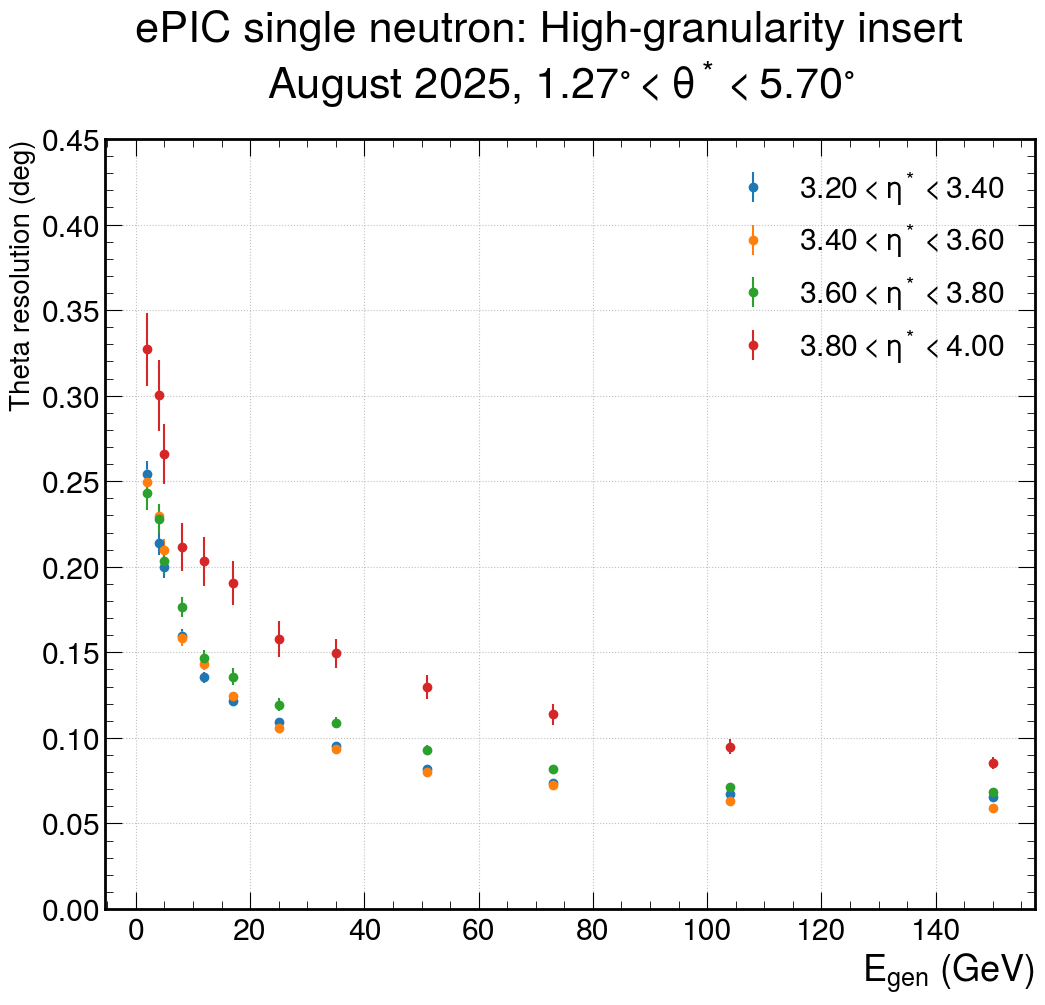

In [11]:
fig = plt.figure(figsize=(12,10))
fig.set_facecolor('w')

lower_energy_lim = 2
for i, eta_range in enumerate(eta_bins):
    truth_energy = eta_truth_energies[i]
    energy_mask = truth_energy>=lower_energy_lim
    theta_resolution = np.asarray(eta_theta_resolutions[i][0])/1000*180/np.pi
    theta_resolution_error = np.asarray(eta_theta_resolutions[i][1])/1000*180/np.pi
    plt.errorbar(truth_energy[energy_mask],
                    theta_resolution[energy_mask],
                    yerr = theta_resolution_error[energy_mask],
                    marker='o',
                    linestyle='none',
                    label = f"${eta_range[0]:.2f}<\eta^*<{eta_range[1]:.2f}$")
    

plt.legend()
plt.ylabel("Theta resolution (deg)",  fontsize=20)
plt.xlabel("$E_{gen}$ (GeV)")
plt.ylim(0, .45)
plt.grid()
if granularity=="high_granularity":
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.03)
    else:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$", y=1.01)
else:
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.03)
    else:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$", y=1.01)

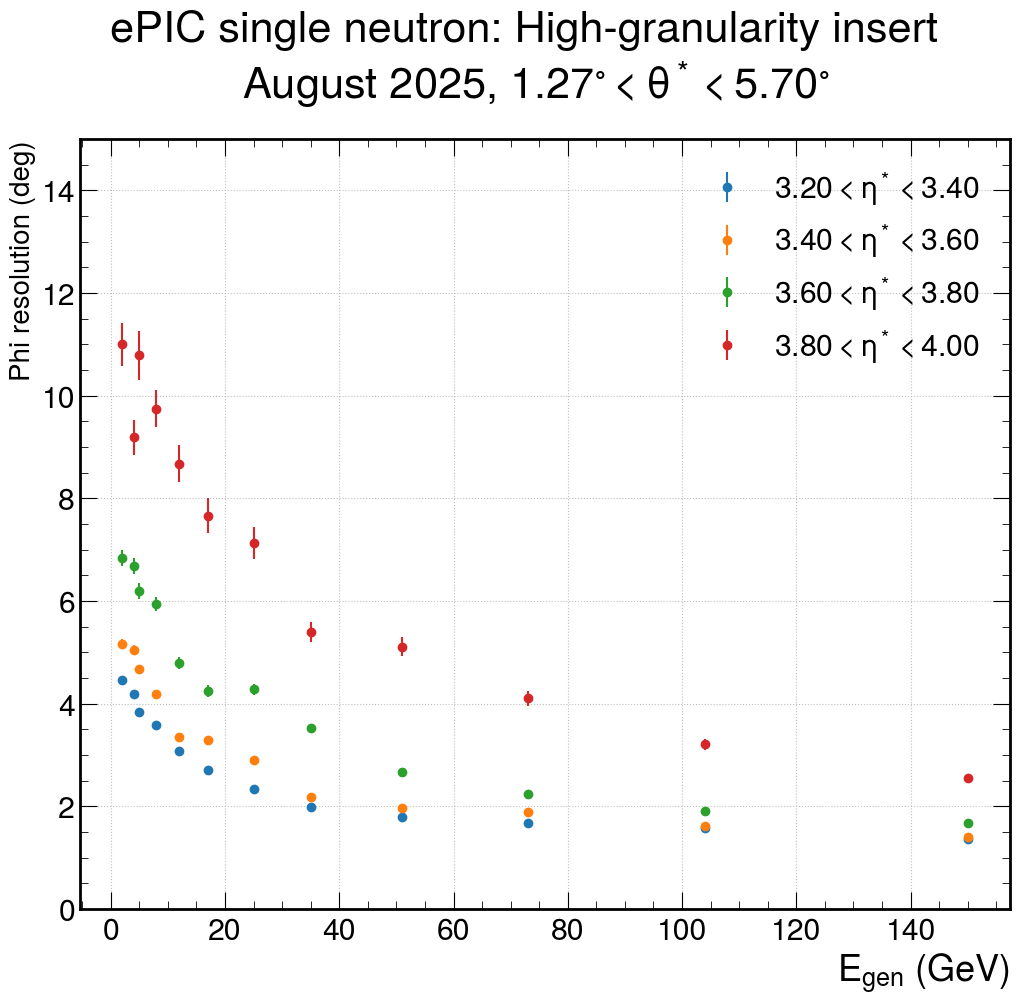

In [12]:
fig = plt.figure(figsize=(12,10))
fig.set_facecolor('w')

lower_energy_lim = 2
for i, eta_range in enumerate(eta_bins):
    truth_energy = eta_truth_energies[i]
    energy_mask = truth_energy>=lower_energy_lim
    phi_resolution = np.asarray(eta_phi_resolutions[i][0])*180/np.pi
    phi_resolution_error = np.asarray(eta_phi_resolutions[i][1])*180/np.pi
    plt.errorbar(truth_energy[energy_mask],
                    phi_resolution[energy_mask],
                    yerr = phi_resolution_error[energy_mask],
                    marker='o',
                    linestyle='none',
                    label = f"${eta_range[0]:.2f}<\eta^*<{eta_range[1]:.2f}$")
    

plt.legend()
plt.ylabel("Phi resolution (deg)",  fontsize=20)
plt.xlabel("$E_{gen}$ (GeV)")
plt.grid()
plt.ylim(0, 15)

if granularity=="high_granularity":
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.03)
    else:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$", y=1.01)
else:
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.03)
    else:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$", y=1.01)